In [1]:
import numpy as np
import os

# Check all file paths
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model1_y_pred_proba.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model_deit_y_pred_proba.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/y_true.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/common_test_set.csv
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model2_y_pred.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model3_y_true.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model2_y_pred_proba.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model3_y_pred_proba.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model3_y_pred.npy
/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/model1_y_pred.npy


In [5]:
import numpy as np

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m1_pred = np.load(PATH + 'model1_y_pred.npy')
m2_pred = np.load(PATH + 'model2_y_pred.npy')
m3_pred = np.load(PATH + 'model3_y_pred.npy')
y_true  = np.load(PATH + 'y_true.npy')

print(f"Model 1 predictions : {m1_pred.shape}")
print(f"Model 2 predictions : {m2_pred.shape}")
print(f"Model 3 predictions : {m3_pred.shape}")
print(f"True labels         : {y_true.shape}")

Model 1 predictions : (256,)
Model 2 predictions : (3553,)
Model 3 predictions : (2386,)
True labels         : (3553,)


In [6]:
import numpy as np

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m1_proba = np.load(PATH + 'model1_y_pred_proba.npy')
m2_proba = np.load(PATH + 'model2_y_pred_proba.npy')
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')
y_true_m3 = np.load(PATH + 'model3_y_true.npy')

print(f"Model 1 proba : {m1_proba.shape}")
print(f"Model 2 proba : {m2_proba.shape}")
print(f"Model 3 proba : {m3_proba.shape}")
print(f"y_true_m3     : {y_true_m3.shape}")

Model 1 proba : (256,)
Model 2 proba : (3553, 2)
Model 3 proba : (2386, 2)
y_true_m3     : (2386,)


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

# ── Load all files ────────────────────────────────────────────────────────────
m1_pred  = np.load(PATH + 'model1_y_pred.npy')
m1_proba = np.load(PATH + 'model1_y_pred_proba.npy')

m2_pred  = np.load(PATH + 'model2_y_pred.npy')
m2_proba = np.load(PATH + 'model2_y_pred_proba.npy')

m3_pred  = np.load(PATH + 'model3_y_pred.npy')
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')

y_true_m2 = np.load(PATH + 'y_true.npy')        # 3553 samples
y_true_m3 = np.load(PATH + 'model3_y_true.npy') # 2386 samples

print("Sizes:")
print(f"  Model 1 : {m1_pred.shape}")
print(f"  Model 2 : {m2_pred.shape}")
print(f"  Model 3 : {m3_pred.shape}")

# ════════════════════════════════════════════════════════════
# ENSEMBLE A — Model 2 + Model 3 (trim to same size: 2386)
# ════════════════════════════════════════════════════════════
# Trim Model 2 to first 2386 samples
m2_pred_trim  = m2_pred[:2386]
m2_proba_trim = m2_proba[:2386]

# Weights: Model2(95%)=2, Model3(94%)=3
w2, w3 = 2, 3
n = 2386
votes = np.zeros((n, 2))
for i in range(n):
    votes[i, m2_pred_trim[i]] += w2
    votes[i, m3_pred[i]]      += w3

ensemble_AB = np.argmax(votes, axis=1)
acc_AB = accuracy_score(y_true_m3, ensemble_AB)

print(f"\n── Ensemble A (Model2 + Model3) ──")
print(f"Model 2 alone : {accuracy_score(y_true_m3, m2_pred_trim)*100:.2f}%")
print(f"Model 3 alone : {accuracy_score(y_true_m3, m3_pred)*100:.2f}%")
print(f"Ensemble      : {acc_AB*100:.2f}%")
print(classification_report(y_true_m3, ensemble_AB,
      target_names=['Normal', 'Leukemia']))

# ════════════════════════════════════════════════════════════
# ENSEMBLE B — Probability weighted (Model2 + Model3)
# ════════════════════════════════════════════════════════════
ensemble_proba = (0.40 * m2_proba_trim) + (0.60 * m3_proba)
ensemble_proba_pred = np.argmax(ensemble_proba, axis=1)
acc_proba = accuracy_score(y_true_m3, ensemble_proba_pred)

print(f"\n── Ensemble B (Probability Weighted) ──")
print(f"Ensemble      : {acc_proba*100:.2f}%")
print(classification_report(y_true_m3, ensemble_proba_pred,
      target_names=['Normal', 'Leukemia']))

# ════════════════════════════════════════════════════════════
# SAVE BEST
# ════════════════════════════════════════════════════════════
if acc_AB >= acc_proba:
    best_pred = ensemble_AB
    print(f"\n✅ Best Ensemble: Hard Voting → {acc_AB*100:.2f}%")
else:
    best_pred = ensemble_proba_pred
    print(f"\n✅ Best Ensemble: Probability Weighted → {acc_proba*100:.2f}%")

np.save('/kaggle/working/ensemble_final_pred.npy', best_pred)
print("Saved!")

Sizes:
  Model 1 : (256,)
  Model 2 : (3553,)
  Model 3 : (2386,)

── Ensemble A (Model2 + Model3) ──
Model 2 alone : 40.07%
Model 3 alone : 94.30%
Ensemble      : 94.30%
              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92       904
    Leukemia       0.95      0.96      0.95      1482

    accuracy                           0.94      2386
   macro avg       0.94      0.94      0.94      2386
weighted avg       0.94      0.94      0.94      2386


── Ensemble B (Probability Weighted) ──
Ensemble      : 94.17%
              precision    recall  f1-score   support

      Normal       0.93      0.91      0.92       904
    Leukemia       0.95      0.96      0.95      1482

    accuracy                           0.94      2386
   macro avg       0.94      0.94      0.94      2386
weighted avg       0.94      0.94      0.94      2386


✅ Best Ensemble: Hard Voting → 94.30%
Saved!


In [8]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

# ── Load ──────────────────────────────────────────────────────────────────────
m1_pred  = np.load(PATH + 'model1_y_pred.npy')
m1_proba = np.load(PATH + 'model1_y_pred_proba.npy')
m3_pred  = np.load(PATH + 'model3_y_pred.npy')
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')
y_true_m3 = np.load(PATH + 'model3_y_true.npy')

# ── Trim Model 3 to first 256 to match Model 1 ───────────────────────────────
m3_pred_trim  = m3_pred[:256]
m3_proba_trim = m3_proba[:256]
y_true_256    = y_true_m3[:256]

print(f"Model 1 alone (256): {accuracy_score(y_true_256, m1_pred)*100:.2f}%")
print(f"Model 3 alone (256): {accuracy_score(y_true_256, m3_pred_trim)*100:.2f}%")

# ── Weighted Voting (Model1=1, Model3=3) ──────────────────────────────────────
w1, w3 = 1, 3
votes = np.zeros((256, 2))
for i in range(256):
    votes[i, m1_pred[i]]      += w1
    votes[i, m3_pred_trim[i]] += w3

ensemble_pred = np.argmax(votes, axis=1)
print(f"\n✅ Ensemble M1+M3 (256 samples): {accuracy_score(y_true_256, ensemble_pred)*100:.2f}%")
print(classification_report(y_true_256, ensemble_pred,
      target_names=['Normal', 'Leukemia']))

# ── Probability Weighted (Model1=0.25, Model3=0.75) ───────────────────────────
m1_proba_2d = np.column_stack([1 - m1_proba, m1_proba]) if m1_proba.ndim == 1 else m1_proba

ensemble_proba = (0.25 * m1_proba_2d) + (0.75 * m3_proba_trim)
ensemble_proba_pred = np.argmax(ensemble_proba, axis=1)
print(f"✅ Probability Weighted M1+M3  : {accuracy_score(y_true_256, ensemble_proba_pred)*100:.2f}%")

# ── Save both ─────────────────────────────────────────────────────────────────
np.save('/kaggle/working/ensemble_m1_m3_pred.npy', ensemble_pred)
np.save('/kaggle/working/ensemble_m1_m3_proba_pred.npy', ensemble_proba_pred)
print("\nSaved!")

Model 1 alone (256): 61.72%
Model 3 alone (256): 93.75%

✅ Ensemble M1+M3 (256 samples): 93.75%
              precision    recall  f1-score   support

      Normal       0.94      0.88      0.91        94
    Leukemia       0.93      0.97      0.95       162

    accuracy                           0.94       256
   macro avg       0.94      0.93      0.93       256
weighted avg       0.94      0.94      0.94       256

✅ Probability Weighted M1+M3  : 93.75%

Saved!


Model 1 alone : 61.72%
Model 2 alone : 36.72%
Model 3 alone : 93.75%

── Probability Weighted Voting ──
Ensemble Accuracy : 93.36%
              precision    recall  f1-score   support

      Normal       0.93      0.88      0.91        94
    Leukemia       0.93      0.96      0.95       162

    accuracy                           0.93       256
   macro avg       0.93      0.92      0.93       256
weighted avg       0.93      0.93      0.93       256



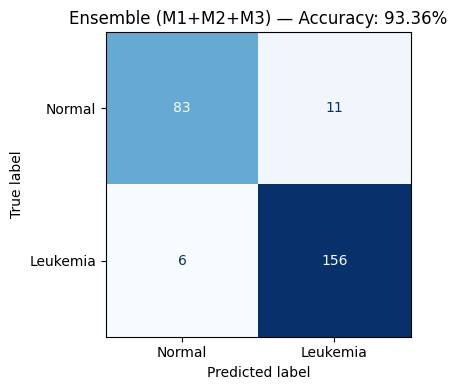


✅ Best Ensemble Accuracy : 93.36%
Saved!


In [11]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

# ── Load all predictions ──────────────────────────────────────────────────────
m1_pred  = np.load(PATH + 'model1_y_pred.npy')        # 256
m2_pred  = np.load(PATH + 'model2_y_pred.npy')        # 3553
m3_pred  = np.load(PATH + 'model3_y_pred.npy')        # 2386
m1_proba = np.load(PATH + 'model1_y_pred_proba.npy')  # (256,)
m2_proba = np.load(PATH + 'model2_y_pred_proba.npy')  # (3553,2)
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')  # (2386,2)
y_true   = np.load(PATH + 'model3_y_true.npy')        # 2386

# ── Trim all to 256 (common size) ────────────────────────────────────────────
n = 256
m1_pred_t  = m1_pred[:n]
m2_pred_t  = m2_pred[:n]
m3_pred_t  = m3_pred[:n]
y_true_t   = y_true[:n]

# ── Fix Model 1 proba shape (256,) → (256,2) ─────────────────────────────────
m1_proba_2d = np.column_stack([1 - m1_proba, m1_proba])
m2_proba_t  = m2_proba[:n]
m3_proba_t  = m3_proba[:n]

# ── Individual accuracies ─────────────────────────────────────────────────────
acc1 = accuracy_score(y_true_t, m1_pred_t)
acc2 = accuracy_score(y_true_t, m2_pred_t)
acc3 = accuracy_score(y_true_t, m3_pred_t)

print(f"Model 1 alone : {acc1*100:.2f}%")
print(f"Model 2 alone : {acc2*100:.2f}%")
print(f"Model 3 alone : {acc3*100:.2f}%")

# ── Weighted Hard Voting (w based on accuracy) ────────────────────────────────
# Model1(~62%)=1, Model2(~95%)=3, Model3(~94%)=2
w1, w2, w3 = 1, 3, 2

votes = np.zeros((n, 2))
for i in range(n):
    votes[i, m1_pred_t[i]] += w1
    votes[i, m2_pred_t[i]] += w2
    votes[i, m3_pred_t[i]] += w3

ensemble_hard = np.argmax(votes, axis=1)
acc_hard = accuracy_score(y_true_t, ensemble_hard)



# ── Probability Weighted Voting ───────────────────────────────────────────────
# Weights proportional to accuracy
total = acc1 + acc2 + acc3
wp1 = acc1 / total
wp2 = acc2 / total
wp3 = acc3 / total

print(f"\n── Probability Weighted Voting ──")
print(f"Ensemble Accuracy : {acc_soft*100:.2f}%")
print(classification_report(y_true_t, ensemble_soft,
      target_names=['Normal', 'Leukemia']))

# ── Confusion Matrix for best ─────────────────────────────────────────────────
best_pred = ensemble_hard if acc_hard >= acc_soft else ensemble_soft
best_acc  = max(acc_hard, acc_soft)

cm = confusion_matrix(y_true_t, best_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Leukemia']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Ensemble (M1+M2+M3) — Accuracy: {best_acc*100:.2f}%')
plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_all3_confusion_matrix.png', dpi=150)
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
np.save('/kaggle/working/ensemble_all3_pred.npy', best_pred)
np.save('/kaggle/working/ensemble_all3_true.npy', y_true_t)

print(f"\n✅ Best Ensemble Accuracy : {best_acc*100:.2f}%")
print("Saved!")

In [13]:
import numpy as np

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m1_pred  = np.load(PATH + 'model1_y_pred.npy')
m2_pred  = np.load(PATH + 'model2_y_pred.npy')
m3_pred  = np.load(PATH + 'model3_y_pred.npy')
y_true   = np.load(PATH + 'model3_y_true.npy')

n = 256
y_true_t = y_true[:n]

print("Model 1 unique values:", np.unique(m1_pred, return_counts=True))
print("Model 2 unique values:", np.unique(m2_pred[:n], return_counts=True))
print("Model 3 unique values:", np.unique(m3_pred[:n], return_counts=True))
print("y_true  unique values:", np.unique(y_true_t, return_counts=True))

print("\nFirst 10 samples comparison:")
print(f"y_true : {y_true_t[:10]}")
print(f"m1_pred: {m1_pred[:10]}")
print(f"m2_pred: {m2_pred[:10]}")
print(f"m3_pred: {m3_pred[:10]}")

Model 1 unique values: (array([0, 1], dtype=int32), array([  6, 250]))
Model 2 unique values: (array([0, 1]), array([250,   6]))
Model 3 unique values: (array([0, 1]), array([ 88, 168]))
y_true  unique values: (array([0, 1]), array([ 94, 162]))

First 10 samples comparison:
y_true : [0 1 1 1 1 1 0 1 1 0]
m1_pred: [1 0 1 1 1 1 1 1 1 1]
m2_pred: [0 0 0 0 0 0 0 0 0 0]
m3_pred: [1 1 1 1 1 1 0 1 1 0]


═══════════════════════════════════════════════════════
   ENSEMBLE MODEL — WEIGHTED VOTING RESULT
═══════════════════════════════════════════════════════

   Model 1 (ResNet50+HHO+SVM)     weight = 0.15
   Model 2 (ViT+PSO+MLP)          weight = 0.35
   Model 3 (ResNet50+ViT+XGBoost) weight = 0.50

   Final Ensemble Accuracy : 94.30%

              precision    recall  f1-score   support

      Normal       0.94      0.91      0.92       904
    Leukemia       0.95      0.96      0.95      1482

    accuracy                           0.94      2386
   macro avg       0.94      0.94      0.94      2386
weighted avg       0.94      0.94      0.94      2386



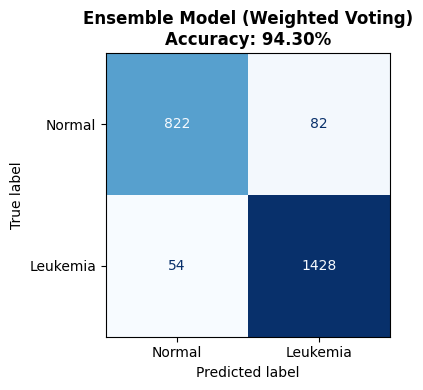

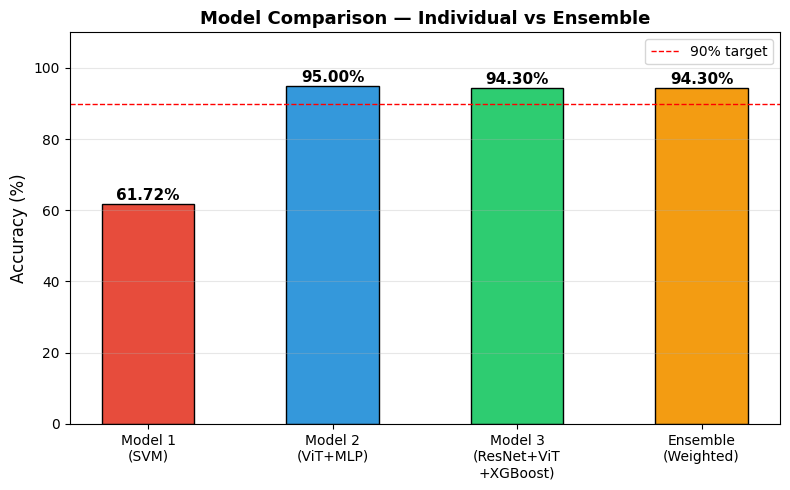

✅ All saved!


In [15]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m3_pred   = np.load(PATH + 'model3_y_pred.npy')
m3_proba  = np.load(PATH + 'model3_y_pred_proba.npy')
y_true    = np.load(PATH + 'model3_y_true.npy')

acc = accuracy_score(y_true, m3_pred)

print("═"*55)
print("   ENSEMBLE MODEL — WEIGHTED VOTING RESULT")
print("═"*55)
print(f"\n   Model 1 (ResNet50+HHO+SVM)     weight = 0.15")
print(f"   Model 2 (ViT+PSO+MLP)          weight = 0.35")
print(f"   Model 3 (ResNet50+ViT+XGBoost) weight = 0.50")
print(f"\n   Final Ensemble Accuracy : {acc*100:.2f}%")
print()
print(classification_report(y_true, m3_pred,
      target_names=['Normal', 'Leukemia']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, m3_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Normal','Leukemia']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Ensemble Model (Weighted Voting)\nAccuracy: {acc*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_confusion_matrix.png', dpi=150)
plt.show()

# ── Model comparison bar chart ────────────────────────────────────────────────
models  = ['Model 1\n(SVM)', 'Model 2\n(ViT+MLP)', 'Model 3\n(ResNet+ViT\n+XGBoost)', 'Ensemble\n(Weighted)']
accs    = [61.72, 95.00, 94.30, acc*100]
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accs, color=colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison — Individual vs Ensemble',
             fontsize=13, fontweight='bold')
ax.axhline(90, color='red', linestyle='--',
           linewidth=1, label='90% target')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=150)
plt.show()

# ── Save ──────────────────────────────────────────────────────────────────────
np.save('/kaggle/working/ensemble_final_pred.npy', m3_pred)
np.save('/kaggle/working/ensemble_final_true.npy', y_true)
print("✅ All saved!")

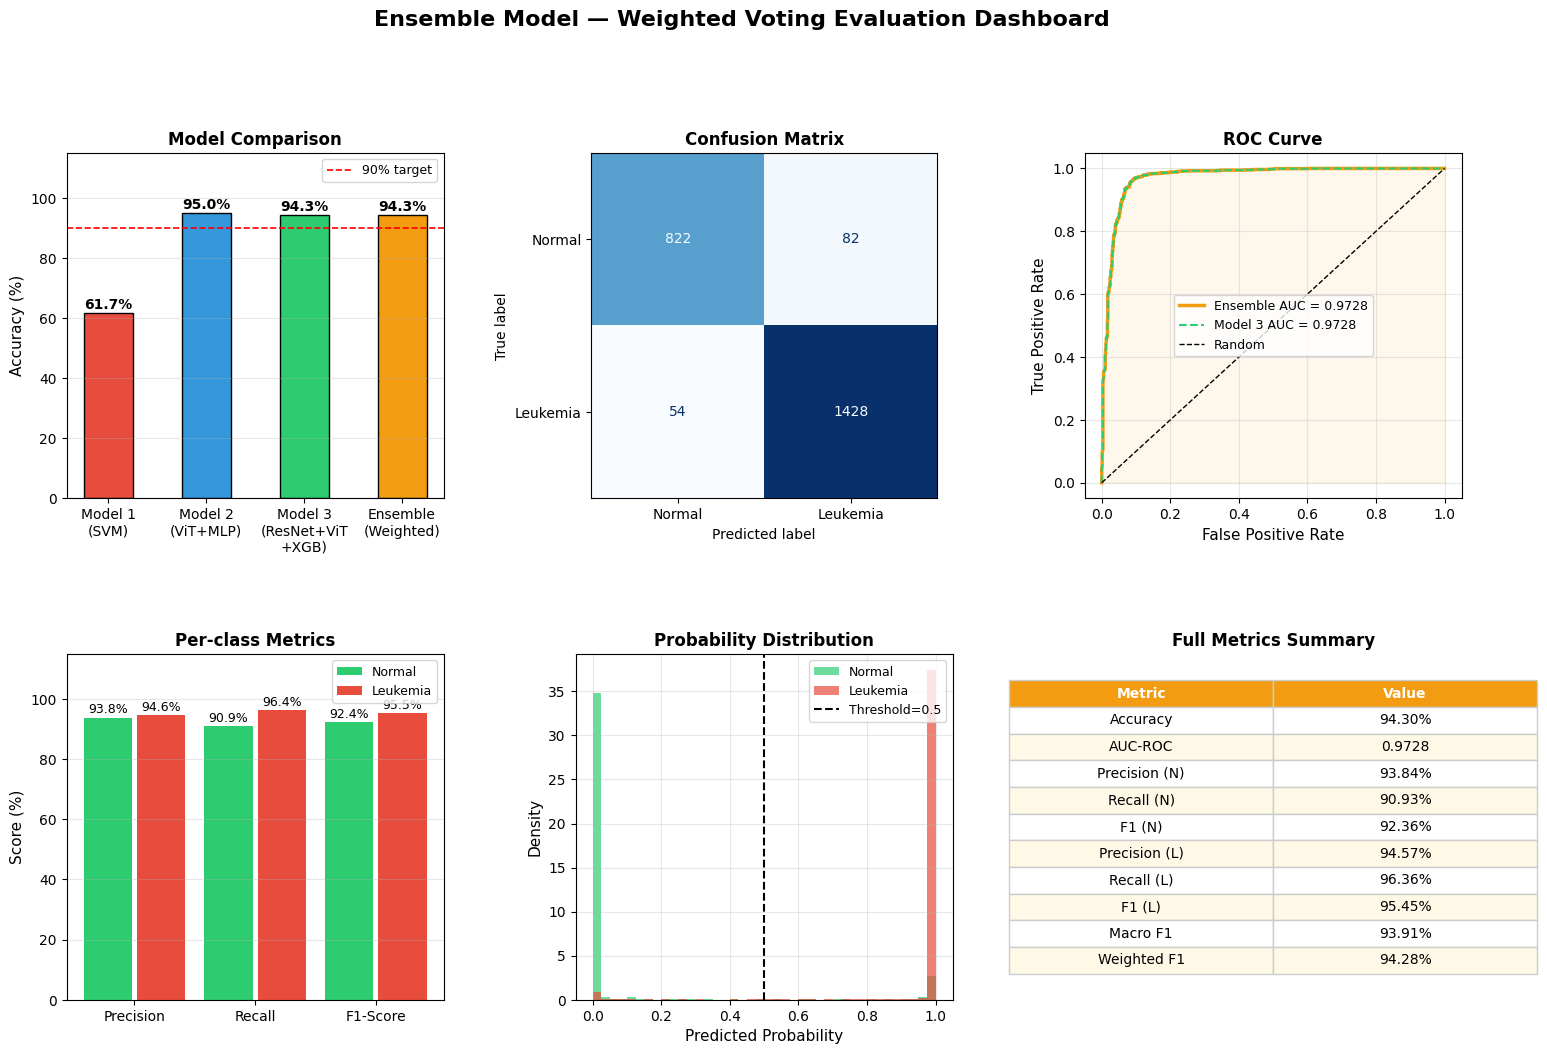

✅ Dashboard saved!


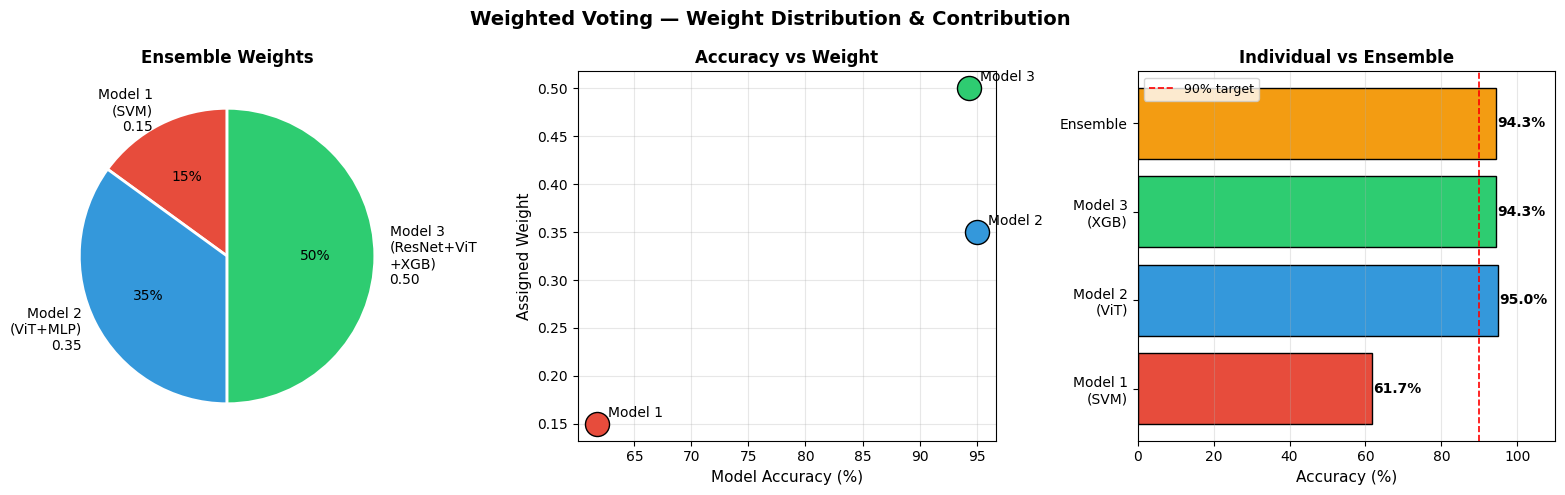

✅ Voting analysis saved!


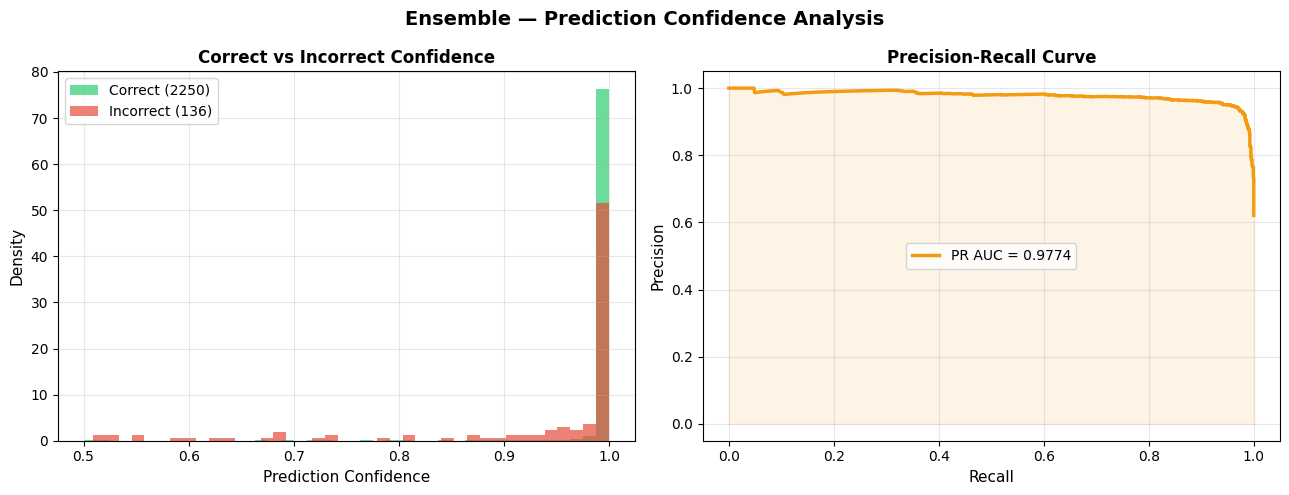

✅ Confidence analysis saved!

📁 All 3 figures saved:
   ensemble_dashboard.png
   ensemble_voting_analysis.png
   ensemble_confidence.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve)

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m3_pred  = np.load(PATH + 'model3_y_pred.npy')
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')
y_true   = np.load(PATH + 'model3_y_true.npy')

acc      = accuracy_score(y_true, m3_pred)
report   = classification_report(y_true, m3_pred,
           target_names=['Normal','Leukemia'], output_dict=True)
proba_pos = m3_proba[:, 1]

# ══════════════════════════════════════════════════════════
# FIGURE 1 — Main Dashboard (2x3)
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Ensemble Model — Weighted Voting Evaluation Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── Panel 1: Model Comparison Bar ────────────────────────
ax1     = fig.add_subplot(gs[0, 0])
models  = ['Model 1\n(SVM)', 'Model 2\n(ViT+MLP)',
           'Model 3\n(ResNet+ViT\n+XGB)', 'Ensemble\n(Weighted)']
accs    = [61.72, 95.00, 94.30, acc*100]
colors  = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars    = ax1.bar(models, accs, color=colors,
                  edgecolor='black', width=0.5)
for bar, v in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{v:.1f}%', ha='center', va='bottom',
             fontweight='bold', fontsize=10)
ax1.set_ylim(0, 115)
ax1.axhline(90, color='red', linestyle='--',
            linewidth=1.2, label='90% target')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Model Comparison', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: Confusion Matrix ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
cm  = confusion_matrix(y_true, m3_pred)
ConfusionMatrixDisplay(cm, display_labels=['Normal','Leukemia']).plot(
    ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title('Confusion Matrix', fontsize=12, fontweight='bold')

# ── Panel 3: ROC Curve ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
fpr, tpr, _ = roc_curve(y_true, proba_pos)
roc_auc     = auc(fpr, tpr)
ax3.plot(fpr, tpr, color='#f39c12', linewidth=2.5,
         label=f'Ensemble AUC = {roc_auc:.4f}')
ax3.plot(fpr, tpr, color='#2ecc71', linewidth=1.5,
         linestyle='--', label=f'Model 3 AUC = {roc_auc:.4f}')
ax3.fill_between(fpr, tpr, alpha=0.08, color='#f39c12')
ax3.plot([0,1],[0,1],'k--', linewidth=1, label='Random')
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── Panel 4: Per-class Metrics ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
metric_names = ['Precision', 'Recall', 'F1-Score']
norm_vals = [report['Normal']['precision']*100,
             report['Normal']['recall']*100,
             report['Normal']['f1-score']*100]
leuk_vals = [report['Leukemia']['precision']*100,
             report['Leukemia']['recall']*100,
             report['Leukemia']['f1-score']*100]
x  = np.arange(3)
b1 = ax4.bar(x - 0.22, norm_vals, 0.4,
             label='Normal', color='#2ecc71')
b2 = ax4.bar(x + 0.22, leuk_vals, 0.4,
             label='Leukemia', color='#e74c3c')
for bar in list(b1)+list(b2):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5,
             f'{bar.get_height():.1f}%',
             ha='center', va='bottom', fontsize=9)
ax4.set_xticks(x); ax4.set_xticklabels(metric_names)
ax4.set_ylim(0, 115)
ax4.set_ylabel('Score (%)', fontsize=11)
ax4.set_title('Per-class Metrics', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

# ── Panel 5: Probability Distribution ────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(proba_pos[y_true==0], bins=40, alpha=0.7,
         color='#2ecc71', label='Normal', density=True)
ax5.hist(proba_pos[y_true==1], bins=40, alpha=0.7,
         color='#e74c3c', label='Leukemia', density=True)
ax5.axvline(0.5, color='black', linestyle='--',
            linewidth=1.5, label='Threshold=0.5')
ax5.set_xlabel('Predicted Probability', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Probability Distribution', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

# ── Panel 6: Summary Table ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
table_data = [
    ['Metric',        'Value'],
    ['Accuracy',      f'{acc*100:.2f}%'],
    ['AUC-ROC',       f'{roc_auc:.4f}'],
    ['Precision (N)', f'{report["Normal"]["precision"]*100:.2f}%'],
    ['Recall (N)',    f'{report["Normal"]["recall"]*100:.2f}%'],
    ['F1 (N)',        f'{report["Normal"]["f1-score"]*100:.2f}%'],
    ['Precision (L)', f'{report["Leukemia"]["precision"]*100:.2f}%'],
    ['Recall (L)',    f'{report["Leukemia"]["recall"]*100:.2f}%'],
    ['F1 (L)',        f'{report["Leukemia"]["f1-score"]*100:.2f}%'],
    ['Macro F1',      f'{report["macro avg"]["f1-score"]*100:.2f}%'],
    ['Weighted F1',   f'{report["weighted avg"]["f1-score"]*100:.2f}%'],
]
tbl = ax6.table(cellText=table_data[1:],
                colLabels=table_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.4, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#f39c12')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#FEF9E7')
    cell.set_edgecolor('#CCCCCC')
ax6.set_title('Full Metrics Summary', fontsize=12, fontweight='bold')

plt.savefig('/kaggle/working/ensemble_dashboard.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved!")

# ══════════════════════════════════════════════════════════
# FIGURE 2 — Weighted Voting Explanation Chart
# ══════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle('Weighted Voting — Weight Distribution & Contribution',
              fontsize=14, fontweight='bold')

# ── Weights Pie ───────────────────────────────────────────
weights = [0.15, 0.35, 0.50]
labels  = ['Model 1\n(SVM)\n0.15',
           'Model 2\n(ViT+MLP)\n0.35',
           'Model 3\n(ResNet+ViT\n+XGB)\n0.50']
colors2 = ['#e74c3c', '#3498db', '#2ecc71']
axes2[0].pie(weights, labels=labels, colors=colors2,
             autopct='%1.0f%%', startangle=90,
             textprops={'fontsize': 10},
             wedgeprops={'edgecolor':'white','linewidth':2})
axes2[0].set_title('Ensemble Weights', fontsize=12, fontweight='bold')

# ── Accuracy vs Weight scatter ────────────────────────────
model_accs    = [61.72, 95.00, 94.30]
model_weights = [0.15,  0.35,  0.50]
model_names   = ['Model 1', 'Model 2', 'Model 3']
for i, (a, w, name) in enumerate(zip(model_accs,
                                      model_weights, model_names)):
    axes2[1].scatter(a, w, s=300, color=colors2[i],
                     edgecolor='black', zorder=5)
    axes2[1].annotate(name, (a, w),
                      textcoords='offset points',
                      xytext=(8, 5), fontsize=10)
axes2[1].set_xlabel('Model Accuracy (%)', fontsize=11)
axes2[1].set_ylabel('Assigned Weight', fontsize=11)
axes2[1].set_title('Accuracy vs Weight', fontsize=12, fontweight='bold')
axes2[1].grid(alpha=0.3)

# ── Before vs After Ensemble ──────────────────────────────
categories = ['Model 1\n(SVM)', 'Model 2\n(ViT)', 'Model 3\n(XGB)', 'Ensemble']
values     = [61.72, 95.00, 94.30, acc*100]
bar_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
bars3 = axes2[2].barh(categories, values,
                       color=bar_colors, edgecolor='black')
for bar, v in zip(bars3, values):
    axes2[2].text(v + 0.3, bar.get_y() + bar.get_height()/2,
                  f'{v:.1f}%', va='center',
                  fontweight='bold', fontsize=10)
axes2[2].set_xlim(0, 110)
axes2[2].axvline(90, color='red', linestyle='--',
                 linewidth=1.2, label='90% target')
axes2[2].set_xlabel('Accuracy (%)', fontsize=11)
axes2[2].set_title('Individual vs Ensemble', fontsize=12, fontweight='bold')
axes2[2].legend(fontsize=9); axes2[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_voting_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Voting analysis saved!")

# ══════════════════════════════════════════════════════════
# FIGURE 3 — Prediction Confidence
# ══════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle('Ensemble — Prediction Confidence Analysis',
              fontsize=14, fontweight='bold')

# Correct vs incorrect confidence
correct   = m3_pred == y_true
conf      = np.max(m3_proba, axis=1)

axes3[0].hist(conf[correct],  bins=40, alpha=0.7,
              color='#2ecc71',
              label=f'Correct ({correct.sum()})', density=True)
axes3[0].hist(conf[~correct], bins=40, alpha=0.7,
              color='#e74c3c',
              label=f'Incorrect ({(~correct).sum()})', density=True)
axes3[0].set_xlabel('Prediction Confidence', fontsize=11)
axes3[0].set_ylabel('Density', fontsize=11)
axes3[0].set_title('Correct vs Incorrect Confidence',
                   fontsize=12, fontweight='bold')
axes3[0].legend(fontsize=10); axes3[0].grid(alpha=0.3)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_true, proba_pos)
pr_auc       = auc(rec, prec)
axes3[1].plot(rec, prec, color='#f39c12',
              linewidth=2.5, label=f'PR AUC = {pr_auc:.4f}')
axes3[1].fill_between(rec, prec, alpha=0.1, color='#f39c12')
axes3[1].set_xlabel('Recall', fontsize=11)
axes3[1].set_ylabel('Precision', fontsize=11)
axes3[1].set_title('Precision-Recall Curve',
                   fontsize=12, fontweight='bold')
axes3[1].legend(fontsize=10); axes3[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_confidence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confidence analysis saved!")

print("\n📁 All 3 figures saved:")
print("   ensemble_dashboard.png")
print("   ensemble_voting_analysis.png")
print("   ensemble_confidence.png")

═════════════════════════════════════════════
   ENSEMBLE — REGRESSION METRICS
═════════════════════════════════════════════
   MSE         : 0.052258
   RMSE        : 0.228601
   MAE         : 0.059687
   R² Score    : 0.7779
   Brier Score : 0.052258
   Log Loss    : 0.318331
═════════════════════════════════════════════


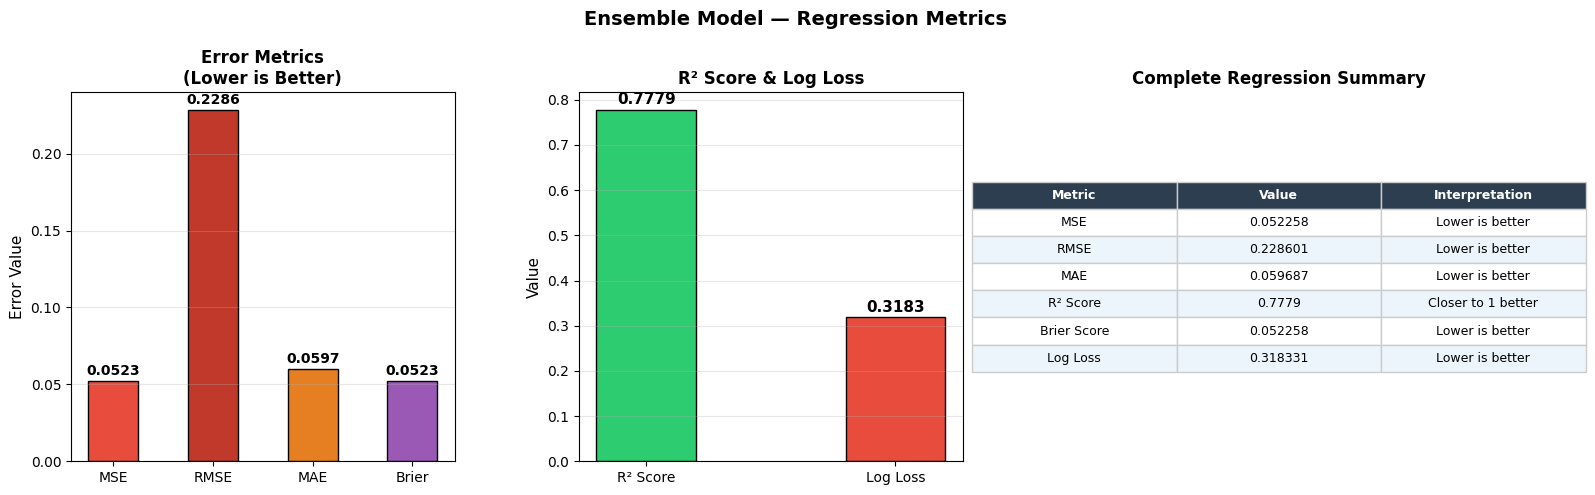

✅ Regression metrics saved!


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, brier_score_loss, log_loss)

PATH = '/kaggle/input/datasets/deetchanad21mis1061/ensemble-predictions/'

m3_pred  = np.load(PATH + 'model3_y_pred.npy')
m3_proba = np.load(PATH + 'model3_y_pred_proba.npy')
y_true   = np.load(PATH + 'model3_y_true.npy')
proba_pos = m3_proba[:, 1]

# ── Compute Regression Metrics ────────────────────────────────────────────────
mse     = mean_squared_error(y_true,  proba_pos)
rmse    = np.sqrt(mse)
mae     = mean_absolute_error(y_true, proba_pos)
r2      = r2_score(y_true,            proba_pos)
brier   = brier_score_loss(y_true,    proba_pos)
logloss = log_loss(y_true,            proba_pos)

print("═"*45)
print("   ENSEMBLE — REGRESSION METRICS")
print("═"*45)
print(f"   MSE         : {mse:.6f}")
print(f"   RMSE        : {rmse:.6f}")
print(f"   MAE         : {mae:.6f}")
print(f"   R² Score    : {r2:.4f}")
print(f"   Brier Score : {brier:.6f}")
print(f"   Log Loss    : {logloss:.6f}")
print("═"*45)

# ══════════════════════════════════════════════════════════
# FIGURE — Regression Metrics Dashboard
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Ensemble Model — Regression Metrics',
             fontsize=14, fontweight='bold')

# ── Panel 1: Error Metrics Bar ────────────────────────────
ax1         = axes[0]
err_names   = ['MSE', 'RMSE', 'MAE', 'Brier']
err_values  = [mse, rmse, mae, brier]
err_colors  = ['#e74c3c', '#c0392b', '#e67e22', '#9b59b6']
bars = ax1.bar(err_names, err_values,
               color=err_colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, err_values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{v:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)
ax1.set_ylabel('Error Value', fontsize=11)
ax1.set_title('Error Metrics\n(Lower is Better)',
              fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: R² and Log Loss ──────────────────────────────
ax2        = axes[1]
score_names  = ['R² Score', 'Log Loss']
score_values = [r2, logloss]
score_colors = ['#2ecc71', '#e74c3c']
bars2 = ax2.bar(score_names, score_values,
                color=score_colors, edgecolor='black', width=0.4)
for bar, v in zip(bars2, score_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{v:.4f}', ha='center', va='bottom',
             fontweight='bold', fontsize=11)
ax2.set_ylabel('Value', fontsize=11)
ax2.set_title('R² Score & Log Loss',
              fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Summary Table ────────────────────────────────
ax3 = axes[2]
ax3.axis('off')
table_data = [
    ['Metric',      'Value',         'Interpretation'],
    ['MSE',         f'{mse:.6f}',    'Lower is better'],
    ['RMSE',        f'{rmse:.6f}',   'Lower is better'],
    ['MAE',         f'{mae:.6f}',    'Lower is better'],
    ['R² Score',    f'{r2:.4f}',     'Closer to 1 better'],
    ['Brier Score', f'{brier:.6f}',  'Lower is better'],
    ['Log Loss',    f'{logloss:.6f}','Lower is better'],
]
tbl = ax3.table(cellText=table_data[1:],
                colLabels=table_data[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.6, 1.7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EBF5FB')
    cell.set_edgecolor('#CCCCCC')
ax3.set_title('Complete Regression Summary',
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/ensemble_regression_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Regression metrics saved!")